# 03 · Anomaly Detection & Segmentation

Goes beyond averages to find **when** the system behaves abnormally and **who** drives performance:

1. **Abnormal-day detection** — a Z-score *system pressure index* on daily dispatch wait per city
2. **Degradation trends** — daily success-rate curves per city
3. **Courier segmentation** — K-Means (k=3): *Elite / Reliable / Risk* profiles
4. **Store segmentation** — K-Means (k=4) on volume, prep time, and cancel rate

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load Data
df = pd.read_csv('../data/operational_data_clean.csv')

## 1. Abnormal-day detection (Z-score)

Days where the average dispatch wait deviates by more than 2 standard deviations from the city mean are flagged as systemic anomalies.

In [2]:
# --- 2. Abnormal Day Detection (Z-Score Logic) ---
daily_metrics = df.groupby(['Order_Date', 'City']).agg(
    Avg_Wait=('Dispatch_Wait_Time', 'mean'),
    Cancel_Rate=('Operational_Status', lambda x: (x == 'Canceled').sum() / len(x))
).reset_index()

# Find outliers where behavior is > 2 standard deviations from city mean
daily_metrics['Wait_Z'] = daily_metrics.groupby('City')['Avg_Wait'].transform(lambda x: (x - x.mean()) / x.std())
abnormal_days = daily_metrics[daily_metrics['Wait_Z'].abs() > 2]

## 2. Performance segments & degradation trend

In [3]:
# Labels: On-Time (<=40), Delayed (40-60), Hyper-Delay (>60)
def get_performance_label(t):
    if pd.isna(t): return 'N/A'
    if t <= 40: return 'On-Time'
    if t <= 60: return 'Delayed'
    return 'Hyper-Delay'

df['Performance_Segment'] = df['Total_Cycle_Time'].apply(get_performance_label)


# Degradation 
daily_success = df.groupby(['Order_Date', 'City']).agg(
    Success_Rate=('Performance_Segment', lambda x: (x == 'On-Time').sum() / len(x) * 100)
).reset_index().sort_values('Order_Date')

## 3. Courier clustering (K-Means, k=3)

In [4]:
df['Biker_Speed'] = (df['Distance_V2C'] / 1000) / (df['Transit_To_Customer_Time'] / 60)
df['Biker_Speed'] = df['Biker_Speed'].replace([np.inf, -np.inf], np.nan)

# Biker Clustering (k=3)
biker_features = df.groupby('DriverID').agg(
    Volume=('OrderID', 'count'),
    Speed=('Biker_Speed', 'mean'),
    Success=('Performance_Segment', lambda x: (x == 'On-Time').sum() / len(x))
).dropna()

scaler = StandardScaler()
b_scaled = scaler.fit_transform(biker_features)
kmeans_b = KMeans(n_clusters=3, random_state=42, n_init=10).fit(b_scaled)
biker_features['Cluster'] = kmeans_b.labels_

## 4. Store clustering (K-Means, k=4)

In [5]:
# Store Clustering (k=4)
store_features = df.groupby('StoreID').agg(
    Volume=('OrderID', 'count'),
    Prep_Time=('At_Vendor_Prep_Time', 'mean'),
    Cancel_Rate=('Operational_Status', lambda x: (x == 'Canceled').sum() / len(x))
).dropna()

s_scaled = scaler.fit_transform(store_features)
kmeans_s = KMeans(n_clusters=4, random_state=42, n_init=10).fit(s_scaled)
store_features['Cluster'] = kmeans_s.labels_

## 5. Combined view

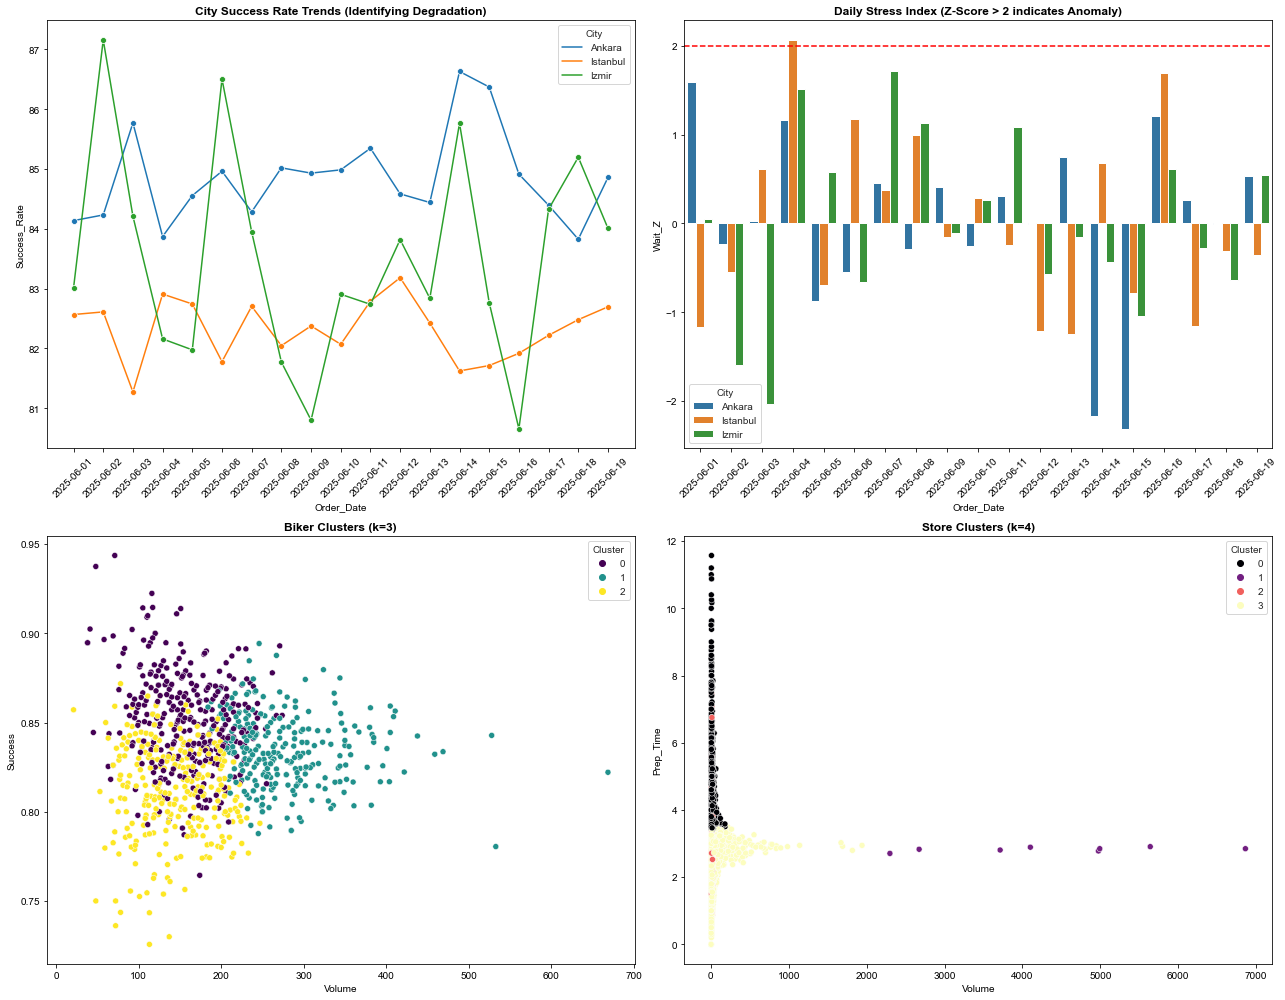

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
sns.set_style("whitegrid")

# Graph 1: Daily Trends (Degradation Check)
sns.lineplot(data=daily_success, x='Order_Date', y='Success_Rate', hue='City', marker='o', ax=axes[0,0])
axes[0,0].set_title('City Success Rate Trends (Identifying Degradation)', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=45)

# Graph 2: Abnormal Spikes
sns.barplot(data=daily_metrics, x='Order_Date', y='Wait_Z', hue='City', ax=axes[0,1])
axes[0,1].axhline(2, color='red', linestyle='--')
axes[0,1].set_title('Daily Stress Index (Z-Score > 2 indicates Anomaly)', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=45)

# Graph 3: Biker Segmentation
sns.scatterplot(data=biker_features, x='Volume', y='Success', hue='Cluster', palette='viridis', ax=axes[1,0])
axes[1,0].set_title('Biker Clusters (k=3)', fontweight='bold')

# Graph 4: Store Segmentation
sns.scatterplot(data=store_features, x='Volume', y='Prep_Time', hue='Cluster', palette='magma', ax=axes[1,1])
axes[1,1].set_title('Store Clusters (k=4)', fontweight='bold')

plt.tight_layout()
plt.savefig('advanced_analytics_dashboard.png')
plt.show()